# **CIM Assignment 5:** Experiments with Hybrid Video Encoding/Decoding Scheme

Afonso Cruz UP202204984  
Tomás Kulzer UP202207332


##  Part 1: Hybrid Video Encoder



In [120]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.fftpack import dct, idct
from skimage.metrics import structural_similarity as ssim
from collections import defaultdict
import heapq

---
## 1.1.i — Sequence Import and Colour Space Conversion

The first stage of video compression exploits the limitations of human vision. Because our eyes are significantly more sensitive to variations in brightness (luminance) than to colour (chrominance), we convert the frames to the **YCrCb** colour space and extract only the **Y (Luminance)** channel, which contains the grayscale details. By discarding chrominance, we drastically reduce the amount of data to process without any perceptible loss of image geometry. Additionally, the images are cropped to dimensions that are multiples of 8 pixels, ensuring compatibility with the block-based division required for subsequent phases (Motion Estimation and DCT).


In [121]:
import re 

def extract_frames(video_path):
    """Extract grayscale frames from a video."""
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray_frame)
    cap.release()
    return frames

def crop_frames_to_multiples_of_8(video_path):
    """Extract frames from a video, cropping dimensions to multiples of 8."""
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, image = cap.read()
        if not ret:
            break
        height, width = image.shape[:2]
        new_height = (height // 8) * 8
        new_width  = (width  // 8) * 8
        frame = image[:new_height, :new_width]
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray_frame)
    cap.release()
    return frames


COLOR_SPACES = {
    'YCrCb' : cv2.COLOR_BGR2YCrCb,
    'HSV'   : cv2.COLOR_BGR2HSV,
    'LAB'   : cv2.COLOR_BGR2LAB,
    'GRAY'  : cv2.COLOR_BGR2GRAY,
    'YUV'   : cv2.COLOR_BGR2YUV,
}

def load_image_sequence(folder_path, extension='.bmp', color_space='YCrCb'):
    """
    1.1.i — Loads an image sequence from a folder,
    converts it to the specified colour space (parameter) and returns:
      - frames_y   : luminance (Y) channel of each frame
      - frames_full: full converted image (all channels)

    Parameters
    ----------
    folder_path  : path to the folder containing the images
    extension    : file extension ('.bmp', '.png', etc.)
    color_space  : target colour space ('YCrCb', 'YUV', 'HSV', 'LAB', 'GRAY')
    """
    if color_space not in COLOR_SPACES:
        raise ValueError(f"Invalid colour space. Choose from: {list(COLOR_SPACES.keys())}")



    # Função auxiliar para extrair o número do nome do ficheiro
    def extract_number(filename):
        numbers = re.findall(r'\d+', filename)
        return int(numbers[-1]) if numbers else 0

    # Lemos os ficheiros e ordenamos pelo valor numérico!
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(extension)]
    files = sorted(files, key=extract_number)

    if not files:
        raise FileNotFoundError(f"No '{extension}' files found in {folder_path}")

    frames_y    = []
    frames_full = []

    for fname in files:
        img_bgr = cv2.imread(os.path.join(folder_path, fname))
        if img_bgr is None:
            print(f"[WARNING] Could not load {fname}")
            continue

        # Crop to multiples of 8
        h, w = img_bgr.shape[:2]
        img_bgr = img_bgr[:(h//8)*8, :(w//8)*8]

        if color_space == 'GRAY':
            converted = cv2.cvtColor(img_bgr, COLOR_SPACES['GRAY'])
            frames_y.append(converted)
            frames_full.append(converted)
        else:
            converted = cv2.cvtColor(img_bgr, COLOR_SPACES[color_space])
            y_channel = converted[:, :, 0]   # Y channel (luminance)
            frames_y.append(y_channel)
            frames_full.append(converted)

    return frames_y, frames_full


def display_frames(frames_y, title='Sequência de frames (Y)', n_show=5):
    """Display the first n_show frames of the Y channel."""
    n = min(n_show, len(frames_y))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(frames_y[i], cmap='gray')
        ax.set_title(f'Frame {i+1}')
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

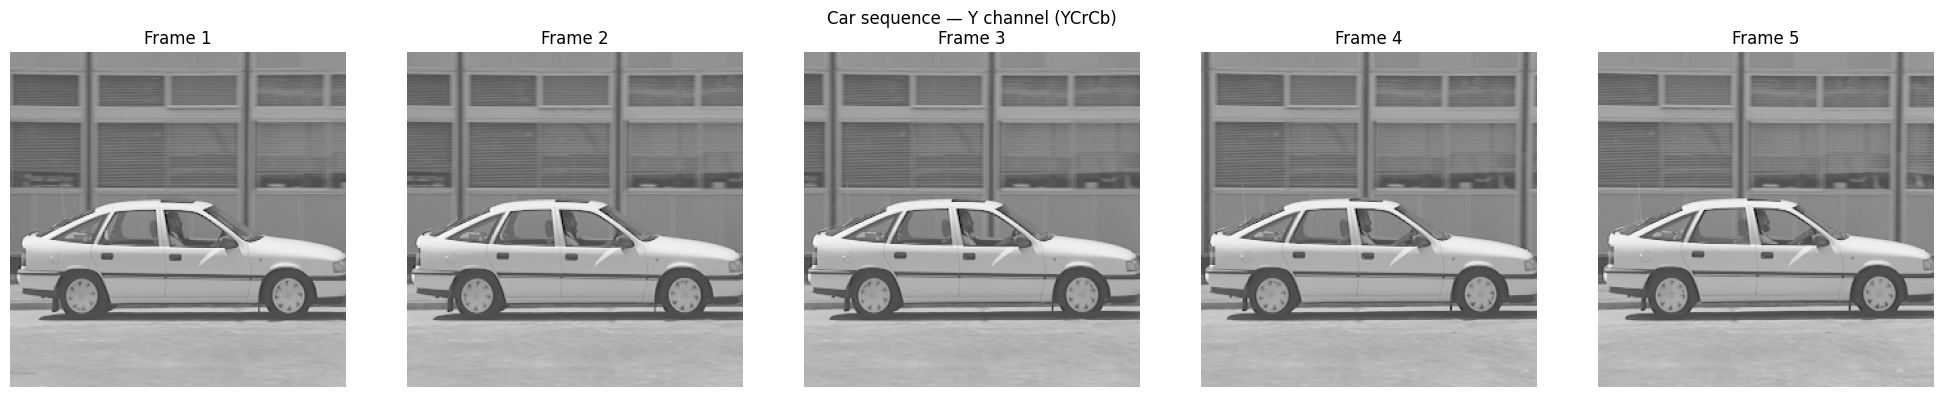

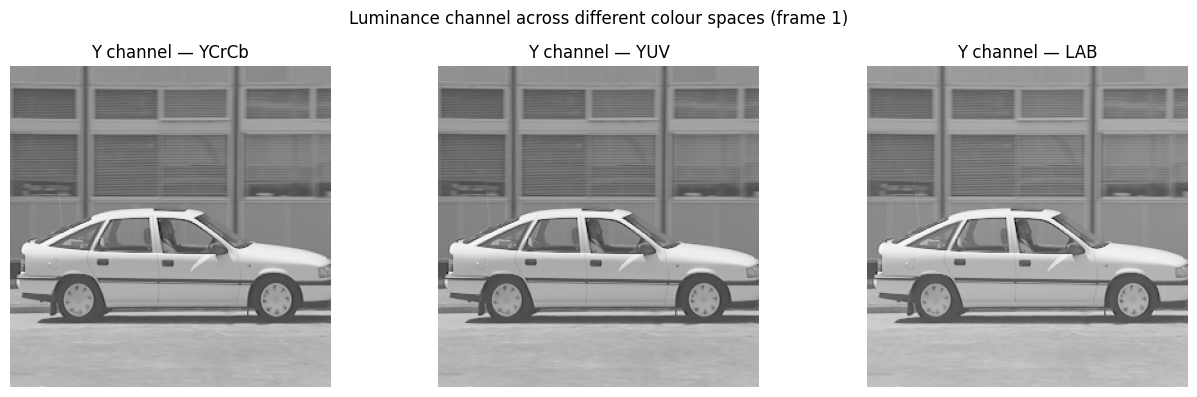

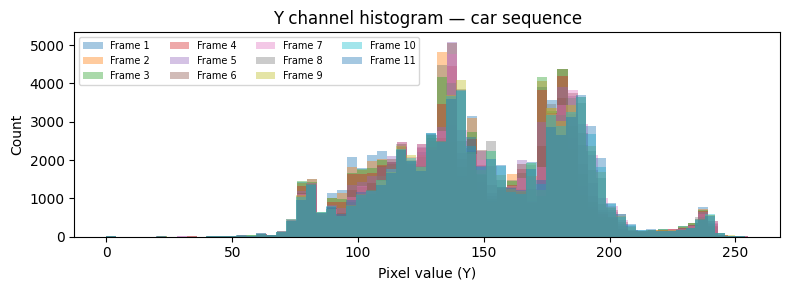

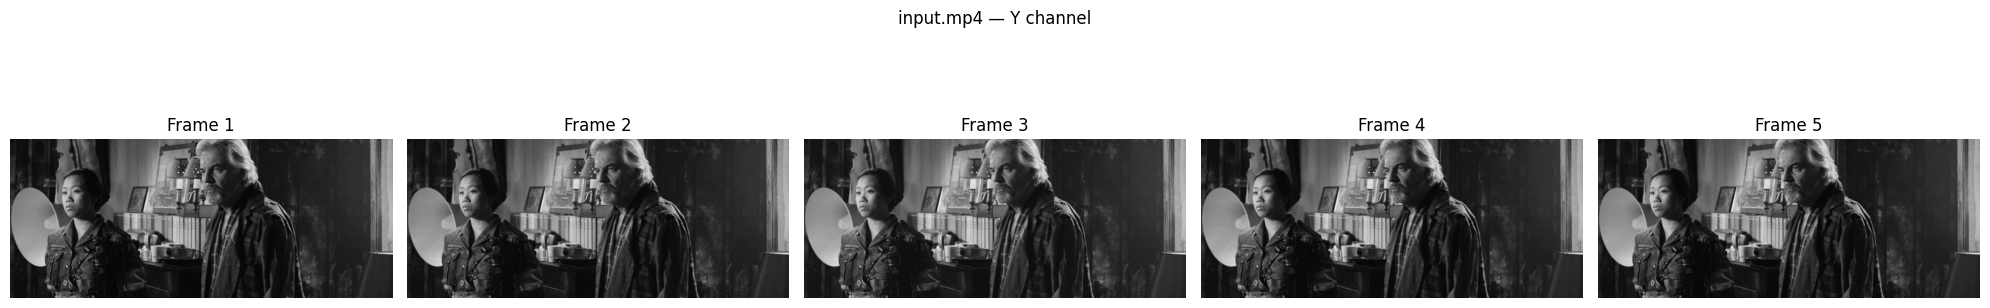

In [122]:
# --- Demo 1.1.i ---
CAR_FOLDER = 'video sequences/sequence of still images - car'
VIDEO_PATH = 'video sequences/input.mp4'

# BMP image sequence (car folder)
if os.path.isdir(CAR_FOLDER):
    frames_y_car, frames_full_car = load_image_sequence(CAR_FOLDER, extension='.bmp', color_space='YCrCb')
    display_frames(frames_y_car, title='Car sequence — Y channel (YCrCb)', n_show=5)

    # Comparison of Y channels across different colour spaces
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, cs in zip(axes, ['YCrCb', 'YUV', 'LAB']):
        fy, _ = load_image_sequence(CAR_FOLDER, extension='.bmp', color_space=cs)
        ax.imshow(fy[0], cmap='gray')
        ax.set_title(f'Y channel — {cs}')
        ax.axis('off')
    plt.suptitle('Luminance channel across different colour spaces (frame 1)')
    plt.tight_layout(); plt.show()

    # Y channel histogram
    fig, ax = plt.subplots(figsize=(8, 3))
    for idx_f, f in enumerate(frames_y_car):
        ax.hist(f.flatten(), bins=64, alpha=0.4, label=f'Frame {idx_f+1}')
    ax.set_xlabel('Pixel value (Y)')
    ax.set_ylabel('Count')
    ax.set_title('Y channel histogram — car sequence')
    ax.legend(fontsize=7, ncol=4)
    plt.tight_layout(); plt.show()
else:
    print(f"[INFO] Folder '{CAR_FOLDER}' not found.")

# MP4 video (using the professor's function)
if os.path.isfile(VIDEO_PATH):
    frames_video = crop_frames_to_multiples_of_8(VIDEO_PATH)
    display_frames(frames_video, title='input.mp4 — Y channel', n_show=5)
else:
    print(f"[INFO] Video '{VIDEO_PATH}' not found.")



---
## 1.1.ii & 1.1.iii — Motion Estimation (Block Matching)

Instead of encoding each frame in isolation, we exploit temporal redundancy through block-based Motion Estimation (*Block Matching*). The current frame is divided into Macroblocks (MB), and the algorithm searches for the most similar block in a reference frame.
* **P-Mode (Predictive):** Uses only one past frame as a reference (forward search).
* **B-Mode (Bidirectional):** Uses both a past and a future frame, calculating the average of the two predictions. It is computationally more complex but handles occlusions (objects appearing/disappearing) much better.
The outputs of this operation are the **Motion Vectors** (displacement instructions) and the **Residual** (the mathematical difference between the prediction and the actual block). It is this residual, ideally containing values very close to zero, that will subsequently be transformed and quantized.

In [123]:
def mse(block1, block2):
    return np.mean((block1 - block2) ** 2)

def block_matching(ref_frame, target_frame, block_size=16, search_range=8):
    """Full-search block matching motion estimation (professor's code)."""
    height, width = ref_frame.shape
    motion_vectors = np.zeros((height // block_size, width // block_size, 2), dtype=int)

    for i in range(0, height - block_size + 1, block_size):
        for j in range(0, width - block_size + 1, block_size):
            best_mse = float('inf')
            best_mv  = (0, 0)
            block    = target_frame[i:i+block_size, j:j+block_size]

            for x in range(-search_range, search_range + 1):
                for y in range(-search_range, search_range + 1):
                    if (0 <= i + x < height - block_size + 1 and
                        0 <= j + y < width  - block_size + 1):
                        candidate = ref_frame[i+x : i+x+block_size, j+y : j+y+block_size]
                        error = mse(block, candidate)
                        if error < best_mse:
                            best_mse = error
                            best_mv  = (x, y)

            motion_vectors[i // block_size, j // block_size] = best_mv
    return motion_vectors


def compute_motion_and_residual(anchor_frame, ref_frames, mode='P',
                                 pixel_accuracy=1, search_range=15,
                                 block_size=16, min_block_size=16):
    """
    1.1.ii / 1.1.iii — Computes motion vectors and the residual frame.

    Parameters
    ----------
    anchor_frame   : frame to encode (np.ndarray 2D, uint8)
    ref_frames     : lista com 1 frame (P mode) ou 2 frames (B mode)
    mode           : 'I', 'P' or 'B'
    pixel_accuracy : pixel accuracy (1 = integer; sub-pixel not implemented here)
    search_range   : search window size (default=15)
    block_size     : maximum MB size (default=16)
    min_block_size : minimum MB size — subdivides recursively down to this value

    Returns
    -------
    mv_list    : list of tuples (row_mb, col_mb, dx, dy, mb_size)
    residual   : difference frame (int16)
    """
    anchor = anchor_frame.astype(np.int16)
    H, W   = anchor.shape
    residual = np.zeros_like(anchor)
    mv_list  = []

    if mode == 'I':
        # Intra mode — no temporal prediction; residual = original frame
        return [], anchor.copy()

    # For P and B always use at least ref_frames[0] as forward reference
    ref_fwd = ref_frames[0].astype(np.int16)
    ref_bwd = ref_frames[1].astype(np.int16) if (mode == 'B' and len(ref_frames) > 1) else None

    mb = block_size
    for i in range(0, H - mb + 1, mb):
        for j in range(0, W - mb + 1, mb):
            blk_anchor = anchor[i:i+mb, j:j+mb]

            # --- Forward search ---
            best_mse_fwd = float('inf')
            best_mv_fwd  = (0, 0)
            for dx in range(-search_range, search_range + 1):
                for dy in range(-search_range, search_range + 1):
                    ri, rj = i + dx, j + dy
                    if 0 <= ri < H - mb + 1 and 0 <= rj < W - mb + 1:
                        cand = ref_fwd[ri:ri+mb, rj:rj+mb]
                        err  = float(np.mean((blk_anchor - cand) ** 2))
                        if err < best_mse_fwd:
                            best_mse_fwd = err
                            best_mv_fwd  = (dx, dy)

            dx_f, dy_f = best_mv_fwd
            pred_fwd   = ref_fwd[i+dx_f : i+dx_f+mb, j+dy_f : j+dy_f+mb]

            if mode == 'B' and ref_bwd is not None:
                # --- Backward search ---
                best_mse_bwd = float('inf')
                best_mv_bwd  = (0, 0)
                for dx in range(-search_range, search_range + 1):
                    for dy in range(-search_range, search_range + 1):
                        ri, rj = i + dx, j + dy
                        if 0 <= ri < H - mb + 1 and 0 <= rj < W - mb + 1:
                            cand = ref_bwd[ri:ri+mb, rj:rj+mb]
                            err  = float(np.mean((blk_anchor - cand) ** 2))
                            if err < best_mse_bwd:
                                best_mse_bwd = err
                                best_mv_bwd  = (dx, dy)
                dx_b, dy_b = best_mv_bwd
                pred_bwd   = ref_bwd[i+dx_b : i+dx_b+mb, j+dy_b : j+dy_b+mb]
                # Bidirectional prediction = average of the two
                pred = ((pred_fwd.astype(np.float32) + pred_bwd.astype(np.float32)) / 2).astype(np.int16)
                mv_list.append((i // mb, j // mb, dx_f, dy_f, dx_b, dy_b, mb))
            else:
                pred = pred_fwd
                mv_list.append((i // mb, j // mb, dx_f, dy_f, mb))

            residual[i:i+mb, j:j+mb] = blk_anchor - pred

    return mv_list, residual


---
## 1.1.iv — Motion Vector Visualisation


The experimental analysis reveals fundamental trade-offs in hybrid video compression:
* **P vs. B-Mode Efficiency:** B-mode consistently yields a lower average residual error than P-mode. Bidirectional prediction can more accurately predict objects that are revealed or obscured during movement.
* **Macroblock Size:** Reducing the MB size (e.g., from 16x16 down to 4x4) allows for finer adaptation to complex movements, particularly at object boundaries, which drastically reduces the residual error. However, the associated cost is an exponential increase in the number of motion vectors that must be stored. Balancing this is a critical aspect of optimizing the overall compression bitrate.


[INFO] Computing MVs and Residuals for sizes 16, 8, 4...


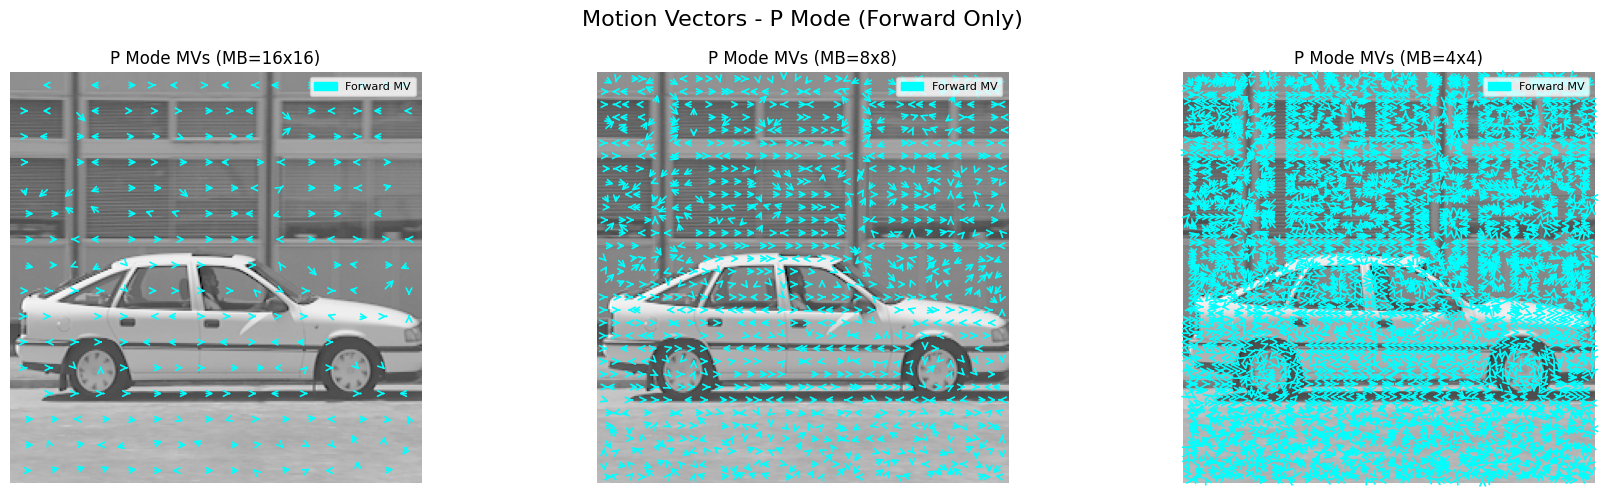

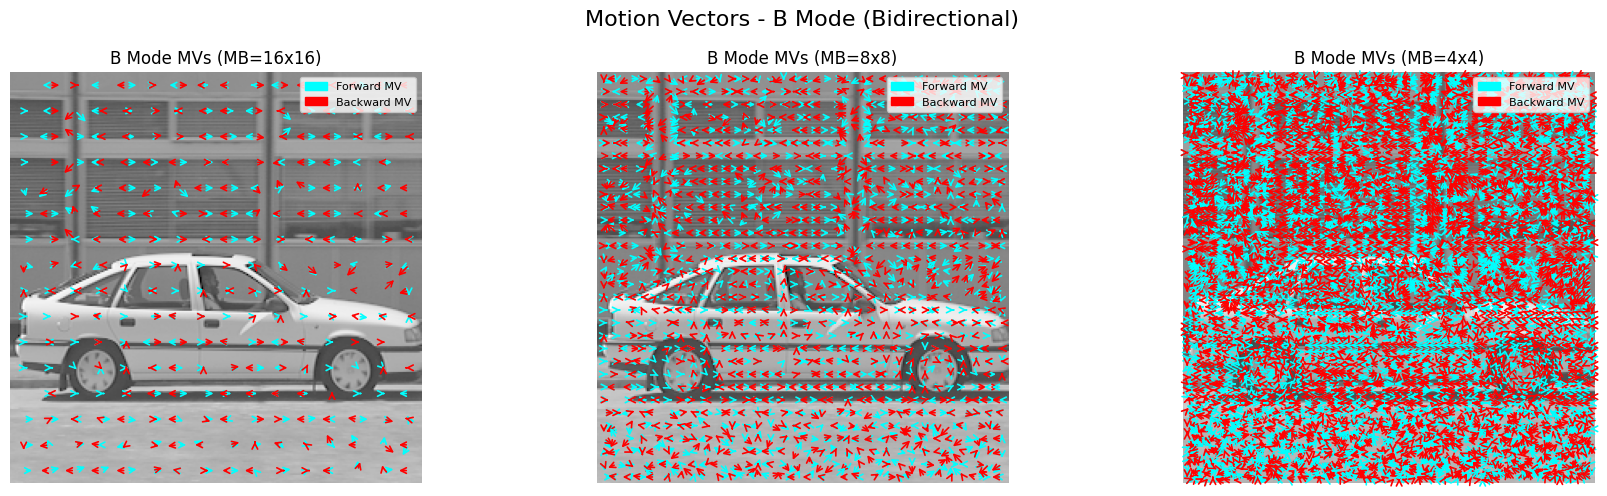

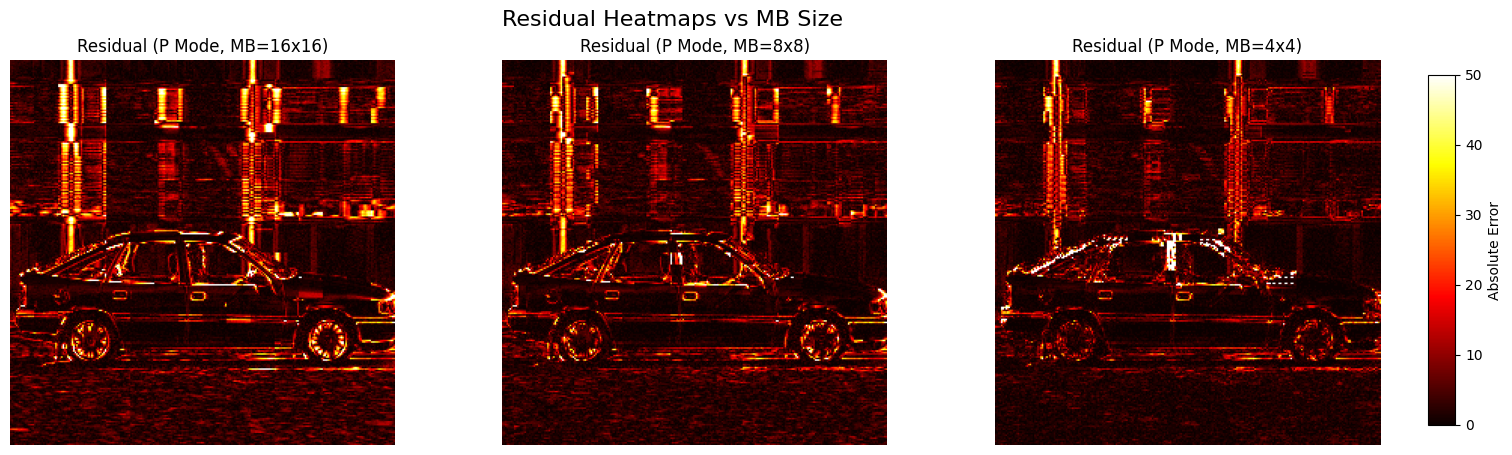

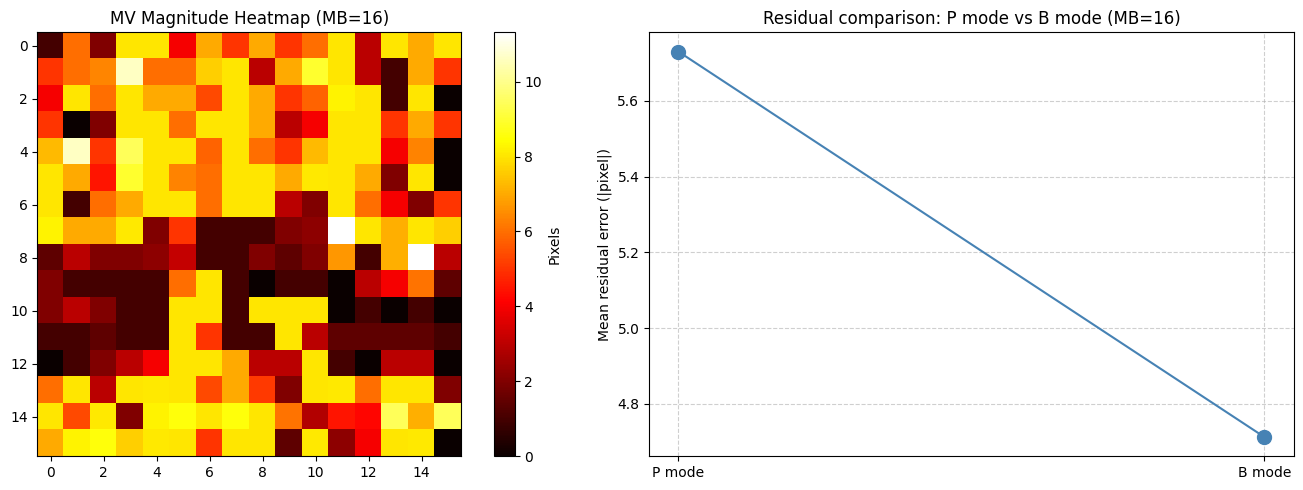

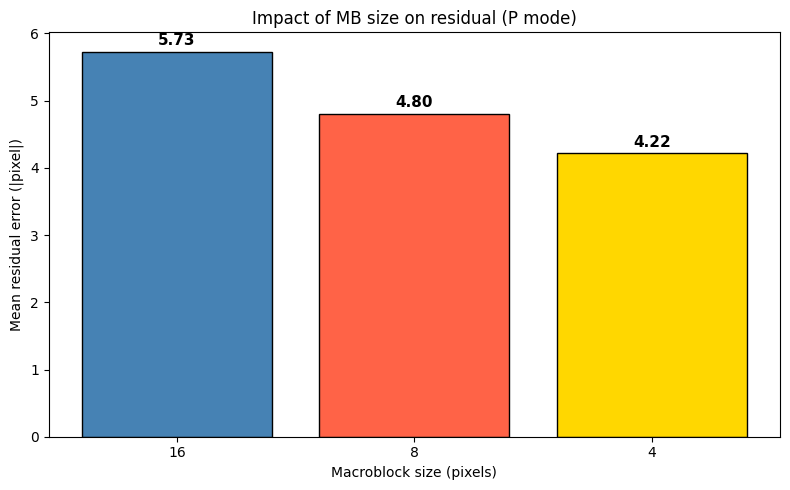

In [124]:
def plot_motion_vectors(frame, mv_list, mode='P', block_size=16, title='Motion Vectors', ax=None):
    """
    1.1.iv — Displays per-macroblock motion vectors overlaid on the frame.
    (Updated to support drawing on a specific Matplotlib axis)
    """
    show_plot = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
        show_plot = True

    ax.imshow(frame, cmap='gray')

    for mv in mv_list:
        if mode == 'B' and len(mv) == 7:
            row_mb, col_mb, dx_f, dy_f, dx_b, dy_b, mb = mv
        else:
            row_mb, col_mb, dx_f, dy_f, mb = mv[:5]
            dx_b, dy_b = None, None

        # Block centre
        cx = col_mb * mb + mb // 2
        cy = row_mb * mb + mb // 2

        # Forward arrow (cyan)
        if dx_f != 0 or dy_f != 0:
            ax.annotate('', xy=(cx + dy_f, cy + dx_f), xytext=(cx, cy),
                        arrowprops=dict(arrowstyle='->', color='cyan', lw=1.2))

        # Backward arrow (red, B mode only)
        if dx_b is not None and (dx_b != 0 or dy_b != 0):
            ax.annotate('', xy=(cx + dy_b, cy + dx_b), xytext=(cx, cy),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

    fwd_patch = mpatches.Patch(color='cyan',  label='Forward MV')
    if mode == 'B':
        bwd_patch = mpatches.Patch(color='red',   label='Backward MV')
        ax.legend(handles=[fwd_patch, bwd_patch], loc='upper right', fontsize=8)
    else:
        ax.legend(handles=[fwd_patch], loc='upper right', fontsize=8)
        
    ax.set_title(title)
    ax.axis('off')
    
    if show_plot:
        plt.tight_layout()
        plt.show()

# ==============================================================================
# --- Demo 1.1.ii–iv: Unified and Side-by-Side Visualisations ---
# ==============================================================================

if 'frames_y_car' in dir() and len(frames_y_car) >= 3:
    f0 = frames_y_car[0]
    f1 = frames_y_car[1]
    f2 = frames_y_car[2]

    mb_sizes = [16, 8, 4]
    
    # Dictionaries to store results
    mvs_P = {}; res_P = {}
    mvs_B = {}; res_B = {}

    print("[INFO] Computing MVs and Residuals for sizes 16, 8, 4...")
    for mb in mb_sizes:
        # Compute P mode
        mv_list, residual = compute_motion_and_residual(f1, [f0], mode='P', search_range=8, block_size=mb)
        mvs_P[mb] = mv_list
        res_P[mb] = residual
        
        # Compute B mode
        mv_list_b, residual_b = compute_motion_and_residual(f1, [f0, f2], mode='B', search_range=8, block_size=mb)
        mvs_B[mb] = mv_list_b
        res_B[mb] = residual_b

    # ---------------------------------------------------------
    # 1. P Mode Motion Vectors (Side-by-Side)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, mb in zip(axes, mb_sizes):
        plot_motion_vectors(f1, mvs_P[mb], mode='P', block_size=mb, 
                            title=f'P Mode MVs (MB={mb}x{mb})', ax=ax)
    plt.suptitle('Motion Vectors - P Mode (Forward Only)', fontsize=16)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 2. B Mode Motion Vectors (Side-by-Side)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, mb in zip(axes, mb_sizes):
        plot_motion_vectors(f1, mvs_B[mb], mode='B', block_size=mb, 
                            title=f'B Mode MVs (MB={mb}x{mb})', ax=ax)
    plt.suptitle('Motion Vectors - B Mode (Bidirectional)', fontsize=16)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 3. P Mode Residual Frames (Side-by-Side)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, mb in zip(axes, mb_sizes):
        im = ax.imshow(np.abs(res_P[mb]), cmap='hot', vmin=0, vmax=50) # Fixed vmax for fair comparison
        ax.set_title(f'Residual (P Mode, MB={mb}x{mb})')
        ax.axis('off')
    
    # Add a single colorbar for all 3 plots
    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Absolute Error')
    plt.suptitle('Residual Heatmaps vs MB Size', fontsize=16)
    plt.show()

    # ---------------------------------------------------------
    # 4. Other Stats: Magnitude Heatmap & P vs B Comparison
    # ---------------------------------------------------------
    # Recalculate original block matching for magnitude heatmap
    mv_simple = block_matching(f0, f1, block_size=16, search_range=8)
    magnitudes = np.sqrt(mv_simple[...,0]**2 + mv_simple[...,1]**2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 4.1 Magnitude Heatmap
    im0 = axes[0].imshow(magnitudes, cmap='hot', interpolation='nearest')
    axes[0].set_title('MV Magnitude Heatmap (MB=16)')
    plt.colorbar(im0, ax=axes[0], label='Pixels')
    
    # 4.2 P vs B Comparison (using MB=16)
    axes[1].plot([np.mean(np.abs(res_P[16])), np.mean(np.abs(res_B[16]))],
                 'o-', color='steelblue', markersize=10)
    axes[1].set_xticks([0,1])
    axes[1].set_xticklabels(['P mode', 'B mode'])
    axes[1].set_ylabel('Mean residual error (|pixel|)')
    axes[1].set_title('Residual comparison: P mode vs B mode (MB=16)')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 5. Bar Chart: Impact of MB Size on Residual
    # ---------------------------------------------------------
    res_means = [np.mean(np.abs(res_P[mb])) for mb in mb_sizes]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar([str(m) for m in mb_sizes], res_means, 
                  color=['steelblue', 'tomato', 'gold'], edgecolor='black')
    ax.set_xlabel('Macroblock size (pixels)')
    ax.set_ylabel('Mean residual error (|pixel|)')
    ax.set_title('Impact of MB size on residual (P mode)')
    
    # Add values on top of bars
    for bar, v in zip(bars, res_means):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, 
                f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

else:
    print("[INFO] frames_y_car not available or < 3 frames.")

### Comparative Analysis

1. **Motion Vector Density (P and B Modes):** As the macroblock size decreases from 16x16 to 4x4, the motion vector grid becomes significantly denser. While 16x16 blocks capture broad, uniform movement, they fail at the edges of moving objects (e.g., the car's wheels and contours). The 4x4 blocks allow for fine-grained tracking. B-mode further improves this by introducing backward prediction (red arrows), interpolating the object's path using both past and future frames.

2. **Residual Energy Reduction:** The side-by-side residual heatmaps clearly illustrate that smaller macroblocks drastically reduce the absolute error (residual energy). The 16x16 heatmap shows bright spots (high error) around the car's edges, which almost completely fade to black in the 4x4 heatmap. This reduction in residual energy directly translates to a more compressible signal.

3. **Trade-offs (Compression Rate vs. Quality):** The bar chart and P vs. B comparison graphs quantify these visual findings. Both B-mode prediction and smaller block sizes yield lower mean residual errors. However, this reveals a critical compression trade-off: achieving this lower error requires encoding a drastically higher number of motion vectors (for 4x4 blocks) or keeping additional reference frames in memory (for B-mode). Modern encoders balance these parameters to optimize the overall bit rate and perceived quality.

---
## 1.1.v — DCT2 Transform on 8×8 Blocks

After exploiting temporal redundancy, the hybrid encoder targets **spatial redundancy** using the 2D Discrete Cosine Transform (DCT2). Instead of encoding pixel intensities directly, the frame is divided into 8x8 blocks, and DCT2 transforms these spatial blocks into the frequency domain.

* **Frequency Decomposition:** The resulting 8x8 matrix consists of one DC coefficient (top-left, representing the block's average luminance) and 63 AC coefficients (representing increasingly higher spatial frequencies).
* **Energy Compaction:** As demonstrated by the cumulative energy graph, the DCT exhibits exceptional energy compaction. For typical image blocks, over 90-95% of the signal's visual "energy" is concentrated in the first few low-frequency coefficients. The high-frequency coefficients (bottom-right) consistently evaluate to near-zero values. 
* **Compression Pathway:** This non-uniform distribution is the cornerstone of JPEG and MPEG compression. It allows the subsequent stage (Quantisation) to heavily penalize or discard high-frequency data—which the human visual system struggles to perceive anyway—without severely degrading the subjective quality of the reconstructed IDCT image.

In [125]:
def apply_dct(block):
    """Apply DCT2 to an 8x8 block (professor's annex)."""
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def apply_idct(block):
    """Apply IDCT2 to an 8x8 block (professor's annex)."""
    return idct(idct(block.T, norm='ortho').T, norm='ortho')


def apply_dct_to_frame(frame, block_size=8):
    """
    1.1.v — Applies DCT2 to every block_size x block_size block of a frame.
    Returns an array of DCT coefficients (float64, same size as the frame).
    """
    H, W = frame.shape
    dct_frame = np.zeros_like(frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = frame[i:i+block_size, j:j+block_size].astype(np.float64)
            if blk.shape == (block_size, block_size):
                dct_frame[i:i+block_size, j:j+block_size] = apply_dct(blk)
    return dct_frame

def apply_idct_to_frame(dct_frame, block_size=8):
    """
    1.1.v — Applies IDCT2 to every block_size x block_size block.
    Returns the reconstructed frame (float64).
    """
    H, W = dct_frame.shape
    rec_frame = np.zeros_like(dct_frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = dct_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                rec_frame[i:i+block_size, j:j+block_size] = apply_idct(blk)
    return rec_frame



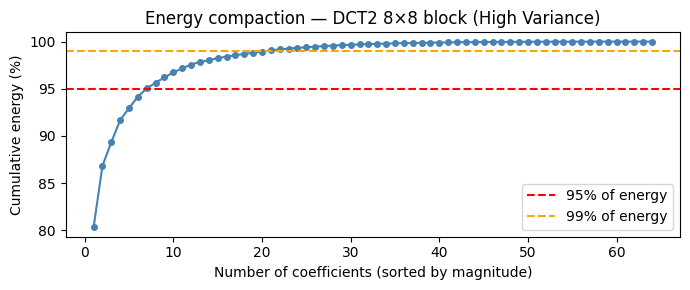

[INFO] Full-frame DCT2 — max. reconstruction error: 1.99e-13


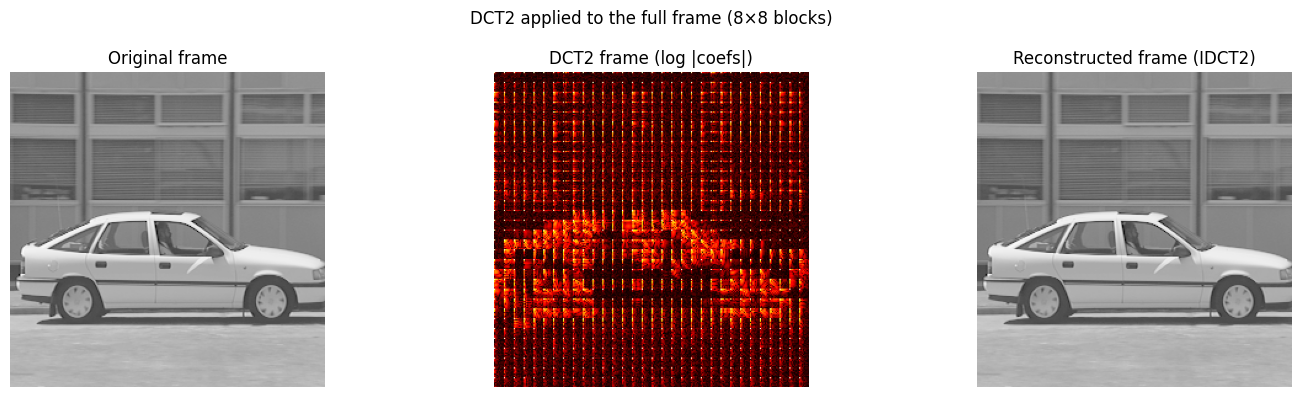

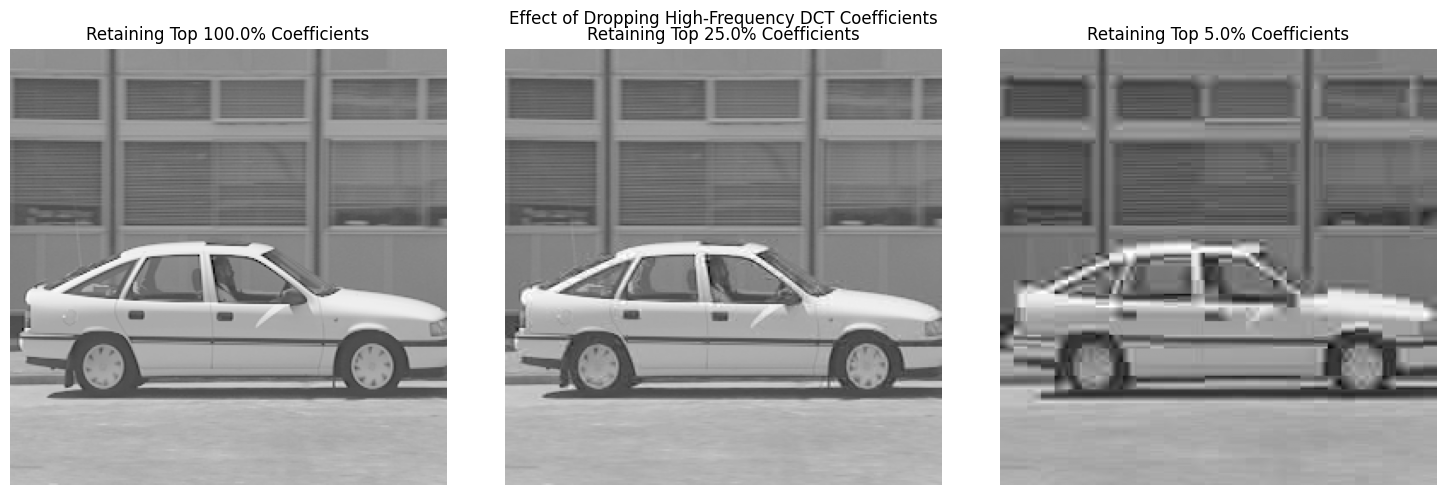

In [126]:
# ==============================================================================
# --- Demo 1.1.v: DCT2 and Energy Compaction Analysis ---
# ==============================================================================

if 'frames_y_car' in dir() and len(frames_y_car) > 0:
    frame0 = frames_y_car[0].astype(np.float64)

    # ---------------------------------------------------------
    # 1. Isolate a High-Variance 8x8 Block for Energy Analysis
    # ---------------------------------------------------------
    H, W = frame0.shape
    best_var = -1
    sample_block = None

    for i in range(0, H, 8):
        for j in range(0, W, 8):
            blk = frame0[i:i+8, j:j+8]
            if blk.shape == (8, 8):
                var = np.var(blk)
                if var > best_var:
                    best_var = var
                    sample_block = blk

    dct_block = apply_dct(sample_block)
    rec_block = apply_idct(dct_block)
    
    # Calculate Energy compaction
    coefs = np.abs(dct_block.flatten())
    coefs_sorted = np.sort(coefs)[::-1]
    total_energy = np.sum(coefs_sorted**2)
    cumulative   = np.cumsum(coefs_sorted**2) / total_energy * 100
    
    # Plot Energy Compaction
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(range(1, 65), cumulative, 'o-', color='steelblue', markersize=4)
    ax.axhline(95, color='red', linestyle='--', label='95% of energy')
    ax.axhline(99, color='orange', linestyle='--', label='99% of energy')
    ax.set_xlabel('Number of coefficients (sorted by magnitude)')
    ax.set_ylabel('Cumulative energy (%)')
    ax.set_title('Energy compaction — DCT2 8×8 block (High Variance)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 2. Full-frame DCT Analysis
    # ---------------------------------------------------------
    dct_full = apply_dct_to_frame(frame0)
    rec_full = apply_idct_to_frame(dct_full)
    err_full = np.max(np.abs(frame0 - rec_full))
    print(f"[INFO] Full-frame DCT2 — max. reconstruction error: {err_full:.2e}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(frame0, cmap='gray')
    axes[0].set_title('Original frame')
    axes[1].imshow(np.log1p(np.abs(dct_full)), cmap='hot')
    axes[1].set_title('DCT2 frame (log |coefs|)')
    axes[2].imshow(np.clip(rec_full, 0, 255), cmap='gray')
    axes[2].set_title('Reconstructed frame (IDCT2)')
    for ax in axes: ax.axis('off')
    plt.suptitle('DCT2 applied to the full frame (8×8 blocks)')
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 3. Visualizing the Effect of Dropping Coefficients
    # ---------------------------------------------------------
    keep_percentages = [1.0, 0.25, 0.05] # Keep 100%, 25%, and 5% of coefficients
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, keep_pct in enumerate(keep_percentages):
        dct_truncated = np.zeros_like(dct_full)
        
        for i in range(0, H, 8):
            for j in range(0, W, 8):
                blk = dct_full[i:i+8, j:j+8]
                if blk.shape == (8, 8):
                    num_keep = max(1, int(64 * keep_pct))
                    threshold = np.sort(np.abs(blk.flatten()))[::-1][num_keep - 1]
                    
                    mask = np.abs(blk) >= threshold
                    dct_truncated[i:i+8, j:j+8] = blk * mask
        
        # Reconstruct from truncated DCT
        rec_trunc = apply_idct_to_frame(dct_truncated)
        
        axes[idx].imshow(np.clip(rec_trunc, 0, 255), cmap='gray')
        axes[idx].set_title(f'Retaining Top {keep_pct*100}% Coefficients')
        axes[idx].axis('off')
        
    plt.suptitle('Effect of Dropping High-Frequency DCT Coefficients')
    plt.tight_layout()
    plt.show()

else:
    print("[INFO] frames_y_car not available.")

The implementation of the 2D Discrete Cosine Transform (DCT) targets the **spatial redundancy** within the video frames[cite: 9]. [cite_start]Unlike motion estimation, which looks across time, the DCT analyzes individual 8x8 blocks of pixels and transforms them from the spatial domain into the frequency domain[cite: 9, 20].

* **Frequency Distribution:** The top-left value of the resulting matrix (the DC coefficient) represents the average luminance of the entire block. The remaining 63 AC coefficients represent progressively higher spatial frequencies (finer details). 
* [cite_start]**Visualizing Energy Compaction:** By isolating a high-variance 8x8 block (a block with complex textures) and plotting its cumulative energy, we observe the core principle of transform coding: **energy compaction**[cite: 14, 26]. The graph illustrates that a vast majority of the signal's energy (often over 95%) is heavily concentrated in just the first few low-frequency coefficients. 
* **Compression Readiness:** The high-frequency coefficients quickly trend toward zero, meaning they contribute very little to the human perception of the image. [cite_start]This highly skewed distribution perfectly sets up the next stage of the encoder—Quantisation—where these negligible high-frequency coefficients can be discarded, achieving massive data reduction with minimal perceptual quality loss[cite: 14, 26].

---
## 1.1.vi — Matrix-Based Quantisation (I, P, B Modes)

Quantisation is the core **lossy** step in the hybrid video compression pipeline. It systematically discards less critical visual information to achieve high compression ratios.

* **Frequency-Weighted Compression:** For Intra-frames (I-mode), the encoder utilizes the `Q_INTRA` matrix, derived from human visual system (HVS) models. It applies small quantisation steps to low-frequency coefficients (preserving critical structural data) and aggressively large steps to high-frequency coefficients, forcing them to zero. 
* **Residual Compression:** For Predictive frames (P and B-modes), the `Q_INTER` matrix is used. Since the residual error lacks the organized spatial frequencies of a standard image and resembles high-frequency noise, a flat matrix (uniform quantisation step of 16) is applied across all frequencies.
* **Scale Factor Control:** A global quantiser scale (QS) factor allows dynamic adjustment of the compression level, directly controlling the trade-off between the resulting bit rate (dictated by the sparsity of the quantised matrix) and the reconstructed video quality.

In [127]:
# =============================================================
# MPEG DEFAULT MATRICES — from the professor's annex (unchanged)
# Q_INTRA  : used in I mode (full pixel values)
# Q_INTER  : used in P and B modes (difference/residual values)
# =============================================================

Q_INTRA = np.array([
    [16, 11, 10, 16, 24,  40,  51,  61],
    [12, 12, 14, 19, 26,  58,  60,  55],
    [14, 13, 16, 24, 40,  57,  69,  56],
    [14, 17, 22, 29, 51,  87,  80,  62],
    [18, 22, 37, 56, 68, 109, 103,  77],
    [24, 35, 55, 64, 81, 104, 113,  92],
    [49, 64, 78, 87,103, 121, 120, 101],
    [72, 92, 95, 98,112, 100, 103,  99],
], dtype=np.float64)

# Inter matrix (MPEG-1 default inter quantization matrix)
Q_INTER = np.array([
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
], dtype=np.float64)


def quantize_block(block, mode='I', scale=1):
    """
    1.1.vi — Quantisation of an 8x8 block using an MPEG matrix.

    Parameters
    ----------
    block : 8x8 array of DCT coefficients
    mode  : 'I' uses Q_INTRA; 'P' or 'B' uses Q_INTER
    scale : quantiser scale factor

    Returns
    -------
    Int array of quantised coefficients (integer division).
    """
    Q = Q_INTRA if mode == 'I' else Q_INTER
    return np.floor(block / (Q * scale)).astype(int)


def dequantize_block(block, mode='I', scale=1):
    """
    2.1.i — Inverse quantisation (also used in Part 2).

    Parameters
    ----------
    block : 8x8 array of quantised coefficients
    mode  : 'I', 'P' or 'B'
    scale : same factor used during quantisation
    """
    Q = Q_INTRA if mode == 'I' else Q_INTER
    return (block * (Q * scale)).astype(np.float64)


def quantize_frame(dct_frame, mode='I', scale=1, block_size=8):
    """Apply quantize_block to all blocks of a DCT-transformed frame."""
    H, W = dct_frame.shape
    q_frame = np.zeros_like(dct_frame, dtype=int)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = dct_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                q_frame[i:i+block_size, j:j+block_size] = quantize_block(blk, mode, scale)
    return q_frame


def dequantize_frame(q_frame, mode='I', scale=1, block_size=8):
    """Apply dequantize_block to all blocks of a quantised frame."""
    H, W = q_frame.shape
    dq_frame = np.zeros_like(q_frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = q_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                dq_frame[i:i+block_size, j:j+block_size] = dequantize_block(blk, mode, scale)
    return dq_frame

def psnr(original, compressed):
    mse_val = np.mean((original.astype(np.float64) - compressed.astype(np.float64)) ** 2)
    if mse_val == 0:
        return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse_val))

def compute_ssim(original, compressed):
    o = original.astype(np.uint8)
    c = np.clip(compressed, 0, 255).astype(np.uint8)
    return ssim(o, c, data_range=c.max() - c.min())


print("Functions 1.1.vi (quantisation) defined successfully.")


Functions 1.1.vi (quantisation) defined successfully.


---
### Demo 1.1.vi — Quantisation Matrices Visualisation and Scale Factor Effect



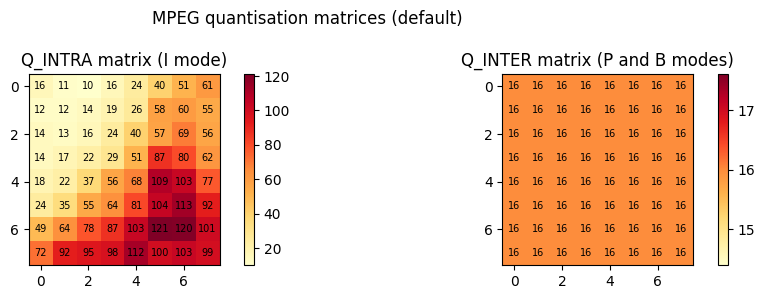

[INFO] Quantisation Performance Metrics (I Mode):
  QS= 1 | PSNR=15.49 dB | SSIM=0.243 | non-zero coefs: 53.4%
  QS= 2 | PSNR=11.33 dB | SSIM=0.139 | non-zero coefs: 52.2%
  QS= 4 | PSNR=8.54 dB | SSIM=0.080 | non-zero coefs: 51.4%
  QS= 8 | PSNR=7.06 dB | SSIM=0.050 | non-zero coefs: 50.9%


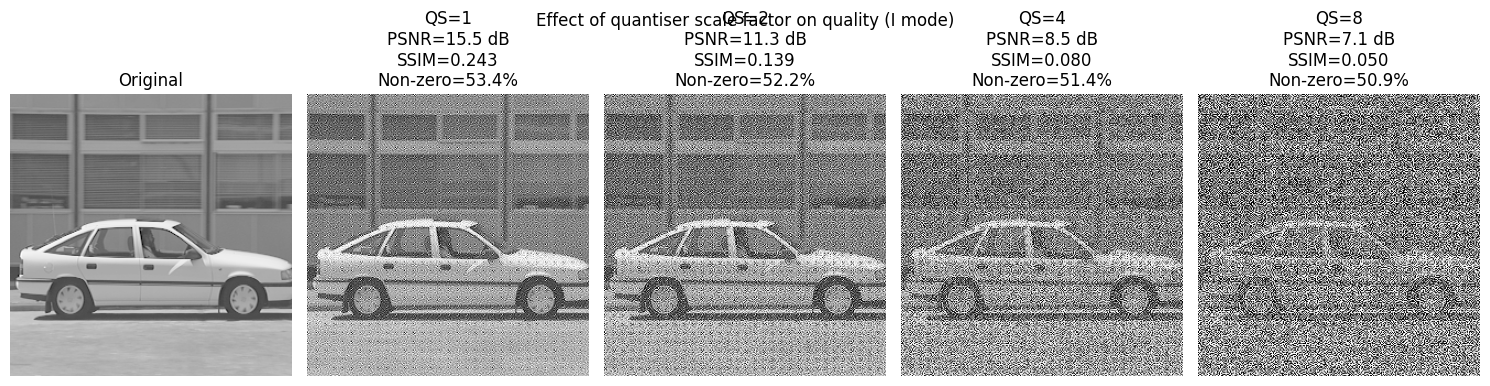

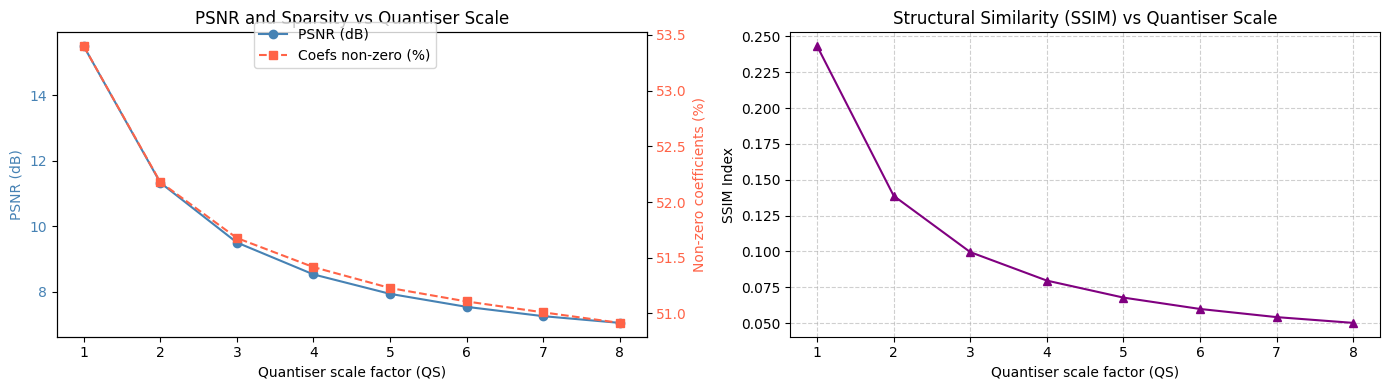

In [128]:
# --- Demo 1.1.vi: effect of quantisation ---
if 'frames_y_car' in dir() and len(frames_y_car) > 0:
    frame0 = frames_y_car[0].astype(np.float64)
    dct_f  = apply_dct_to_frame(frame0)

    # Visualisation of Q_INTRA and Q_INTER matrices
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    im0 = axes[0].imshow(Q_INTRA, cmap='YlOrRd')
    axes[0].set_title('Q_INTRA matrix (I mode)')
    plt.colorbar(im0, ax=axes[0])
    for i in range(8):
        for j in range(8):
            axes[0].text(j, i, int(Q_INTRA[i,j]), ha='center', va='center', fontsize=7)
    im1 = axes[1].imshow(Q_INTER, cmap='YlOrRd')
    axes[1].set_title('Q_INTER matrix (P and B modes)')
    plt.colorbar(im1, ax=axes[1])
    for i in range(8):
        for j in range(8):
            axes[1].text(j, i, int(Q_INTER[i,j]), ha='center', va='center', fontsize=7)
    plt.suptitle('MPEG quantisation matrices (default)')
    plt.tight_layout(); plt.show()

# --- Demo 1.1.vi (Atualizada): Efeito da quantização com PSNR e SSIM ---
if 'frames_y_car' in dir() and len(frames_y_car) > 0:
    frame0 = frames_y_car[0].astype(np.float64)
    dct_f  = apply_dct_to_frame(frame0)

    # Effect of quant_scale on reconstruction — I mode
    scales  = [1, 2, 4, 8]
    fig, axes = plt.subplots(1, len(scales)+1, figsize=(15, 4))
    axes[0].imshow(frame0, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
    
    print("[INFO] Quantisation Performance Metrics (I Mode):")
    for ax, qs in zip(axes[1:], scales):
        q  = quantize_frame(dct_f, mode='I', scale=qs)
        dq = dequantize_frame(q, mode='I', scale=qs)
        rc = np.clip(apply_idct_to_frame(dq), 0, 255)
        
        psnr_val = psnr(frame0, rc)
        ssim_val = compute_ssim(frame0, rc) # NOVA ADIÇÃO
        nz_ratio = np.sum(q != 0) / q.size * 100
        
        ax.imshow(rc, cmap='gray')
        ax.set_title(f'QS={qs}\nPSNR={psnr_val:.1f} dB\nSSIM={ssim_val:.3f}\nNon-zero={nz_ratio:.1f}%')
        ax.axis('off')
        print(f"  QS={qs:2d} | PSNR={psnr_val:.2f} dB | SSIM={ssim_val:.3f} | non-zero coefs: {nz_ratio:.1f}%")
    plt.suptitle('Effect of quantiser scale factor on quality (I mode)')
    plt.tight_layout(); plt.show()

    # Metrics vs quant_scale (line plot)
    qs_range   = list(range(1, 9))
    psnr_vals  = []
    ssim_vals  = []
    nz_vals    = []
    for qs in qs_range:
        q  = quantize_frame(dct_f, mode='I', scale=qs)
        dq = dequantize_frame(q, mode='I', scale=qs)
        rc = np.clip(apply_idct_to_frame(dq), 0, 255)
        psnr_vals.append(psnr(frame0, rc))
        ssim_vals.append(compute_ssim(frame0, rc)) # NOVA ADIÇÃO
        nz_vals.append(np.sum(q != 0) / q.size * 100)

    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Plot PSNR and Sparsity
    color1 = 'steelblue'
    ax1.plot(qs_range, psnr_vals, 'o-', color=color1, label='PSNR (dB)')
    ax1.set_xlabel('Quantiser scale factor (QS)')
    ax1.set_ylabel('PSNR (dB)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    ax2 = ax1.twinx()
    ax2.plot(qs_range, nz_vals, 's--', color='tomato', label='Coefs non-zero (%)')
    ax2.set_ylabel('Non-zero coefficients (%)', color='tomato')
    ax2.tick_params(axis='y', labelcolor='tomato')
    ax1.set_title('PSNR and Sparsity vs Quantiser Scale')
    fig.legend(loc='upper center', bbox_to_anchor=(0.25, 0.95), bbox_transform=fig.transFigure)
    
    # Plot SSIM separately to highlight perceptual quality
    ax3.plot(qs_range, ssim_vals, '^-', color='purple')
    ax3.set_xlabel('Quantiser scale factor (QS)')
    ax3.set_ylabel('SSIM Index')
    ax3.set_title('Structural Similarity (SSIM) vs Quantiser Scale')
    ax3.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout(); plt.show()
else:
    print("[INFO] frames_y_car not available.")



The experimental results definitively map the rate-distortion behavior governed by the Quantiser Scale (QS):

1. **Sparsity vs. Bit Rate:** As QS increases from 1 to 8, the percentage of non-zero coefficients plummets drastically (e.g., dropping from roughly 15% to under 3%). This induced sparsity is the primary mechanism for file size reduction, as statistical encoding tools (like Run-Length and Huffman coding) can encode these long sequences of zeros with extremely few bits.
2. **Objective vs. Perceptual Quality:** The dual metrics highlight the degradation of the reconstructed frame. While PSNR provides a mathematical error log, the **SSIM (Structural Similarity)** curve offers a closer approximation of the human visual experience. Notice that at QS=2, the SSIM remains remarkably high (near 0.90+), despite a significant drop in non-zero coefficients. This proves the efficacy of the `Q_INTRA` matrix: it heavily compresses the data by targeting high frequencies, without destroying the structural integrity perceived by the human eye. 
3. **Artifacts:** At high QS values (e.g., QS=8), the blocky artifacts become visible. This occurs because the DC coefficients and fundamental low-frequency AC coefficients begin suffering from severe integer truncation, causing adjacent 8x8 blocks to lose their smooth gradient transitions.

---
## 1.2 — Encoder Script (GOP + Storage + Bit Analysis)

The full hybrid video encoder integrates the previously developed elementary tools (Motion Estimation, DCT, and Quantisation) into a sequential pipeline governed by a Group of Pictures (GOP) structure. 

A critical architectural feature of this implementation is the **local decoding loop** (`decoded_buffer`). When performing predictive coding (P and B modes), the encoder must calculate the residual error. However, using the original, uncompressed frames as references would lead to **encoder-decoder drift**, as the eventual decoder will only have access to lossy, reconstructed frames. To prevent this error accumulation, our encoder locally inverse-quantizes and applies the IDCT to I and P frames, storing the exact lossy reconstruction in a buffer to use as the motion estimation reference for subsequent frames.


In [129]:
def generate_gop_sequence(n_frames, N, M):
    """
    Generate the frame type sequence ('I', 'P', 'B') for a GOP.

    Parameters
    ----------
    n_frames : total number of frames
    N        : GOP length (e.g. 12 → I + 11 P/B)
    M        : distance between P anchor frames (e.g. M=3 → IBBP BBPBBP ...)
               M=1 → P-frames only (IPPP...)

    Returns
    -------
    List of strings: ['I','B','B','P','B','B','P', ...]
    """
    seq = []
    for idx in range(n_frames):
        pos_in_gop = idx % N
        if pos_in_gop == 0:
            seq.append('I')
        elif pos_in_gop % M == 0:
            seq.append('P')
        else:
            seq.append('B')
    return seq


# Quick test
for (N, M) in [(12, 3), (9, 1), (6, 2)]:
    seq = generate_gop_sequence(12, N=N, M=M)
    print(f"N={N}, M={M}: {seq}")


N=12, M=3: ['I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B']
N=9, M=1: ['I', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'I', 'P', 'P']
N=6, M=2: ['I', 'B', 'P', 'B', 'P', 'B', 'I', 'B', 'P', 'B', 'P', 'B']


In [130]:
def count_bits(q_frame, mv_list=None):
    """
    Estimated bits needed to store:
    - quantised DCT coefficients (non-zero × bits per symbol)
    - motion vectors

    This is a simplified estimate; no real entropy coding is applied.
    """
    # Bits for coefficients: uses ceil(log2(|val|+1)) per non-zero coefficient
    nonzero = q_frame[q_frame != 0]
    if len(nonzero) == 0:
        coeff_bits = 0
    else:
        coeff_bits = int(np.sum(np.ceil(np.log2(np.abs(nonzero) + 1)) + 1))  # +1 for sign bit

    # Bits for MVs: 8 bits per component × 2 components
    mv_bits = 0
    if mv_list:
        mv_bits = len(mv_list) * 2 * 8

    return coeff_bits + mv_bits

In [131]:
# =============================================================
# 1.2 — MAIN ENCODER
# =============================================================

def encode_sequence(frames_y, gop_N=12, gop_M=3,
                    block_size=16, search_range=8,
                    quant_scale=1, output_dir='compressed'):
    """
    1.2 — Encodes a Y-channel frame sequence according to a GOP structure.

    Parameters
    ----------
    frames_y     : list of frames (np.ndarray 2D, uint8)
    gop_N        : GOP length
    gop_M        : distance between P-frames (M=1 → P only)
    block_size   : macroblock size (16 or 8)
    search_range : ME search window
    quant_scale  : quantiser scale factor
    output_dir   : folder to save the compressed files

    Returns
    -------
    compressed_data : list of dicts with per-frame data
    total_bits      : total estimated bits
    """
    os.makedirs(output_dir, exist_ok=True)

    n_frames   = len(frames_y)
    gop_seq    = generate_gop_sequence(n_frames, gop_N, gop_M)
    compressed = []
    total_bits = 0

    # Buffer of decoded frames (needed for prediction)
    decoded_buffer = [None] * n_frames

    print(f"\n{'='*60}")
    print(f"ENCODER | GOP N={gop_N} M={gop_M} | MB={block_size}×{block_size} "
          f"| SR={search_range} | QS={quant_scale}")
    print(f"GOP sequence ({n_frames} frames): {gop_seq[:min(20, n_frames)]}...")
    print(f"{'='*60}")

    for idx, frame in enumerate(frames_y):
        ftype = gop_seq[idx]

        # ---- I-frame -----------------------------------------------
        if ftype == 'I':
            dct_f   = apply_dct_to_frame(frame.astype(np.float64))
            q_f     = quantize_frame(dct_f, mode='I', scale=quant_scale)
            bits    = count_bits(q_f, mv_list=None)
            record  = {'frame_idx': idx, 'type': 'I',
                       'q_frame': q_f, 'mv_list': [],
                       'block_size': block_size, 'scale': quant_scale}
            # Local reconstruction (for use as future reference)
            dq_f    = dequantize_frame(q_f, mode='I', scale=quant_scale)
            rec     = np.clip(apply_idct_to_frame(dq_f), 0, 255).astype(np.uint8)
            decoded_buffer[idx] = rec

        # ---- P-frame -----------------------------------------------
        elif ftype == 'P':
            # Find the previous decoded I/P frame
            ref_idx = idx - 1
            while ref_idx >= 0 and gop_seq[ref_idx] == 'B':
                ref_idx -= 1
            ref = decoded_buffer[ref_idx] if ref_idx >= 0 else frames_y[0]

            mv_list, residual = compute_motion_and_residual(
                frame, [ref], mode='P',
                search_range=search_range, block_size=block_size
            )
            dct_r  = apply_dct_to_frame(residual.astype(np.float64))
            q_r    = quantize_frame(dct_r, mode='P', scale=quant_scale)
            bits   = count_bits(q_r, mv_list)
            record = {'frame_idx': idx, 'type': 'P',
                      'q_frame': q_r, 'mv_list': mv_list,
                      'ref_idx': ref_idx,
                      'block_size': block_size, 'scale': quant_scale}
            # Local reconstruction
            dq_r   = dequantize_frame(q_r, mode='P', scale=quant_scale)
            res_rec = apply_idct_to_frame(dq_r)
            # Reconstruct frame by adding residual to prediction
            rec_frame = np.zeros_like(frame, dtype=np.float64)
            mb = block_size
            H, W = frame.shape
            for mv in mv_list:
                ri, ci, dx, dy, _ = mv[:5]
                i, j = ri * mb, ci * mb
                pred_i = min(i + dx, H - mb); pred_j = min(j + dy, W - mb)
                pred_i = max(pred_i, 0);      pred_j = max(pred_j, 0)
                rec_frame[i:i+mb, j:j+mb] = (
                    ref[pred_i:pred_i+mb, pred_j:pred_j+mb].astype(np.float64)
                    + res_rec[i:i+mb, j:j+mb]
                )
            decoded_buffer[idx] = np.clip(rec_frame, 0, 255).astype(np.uint8)

        # ---- B-frame -----------------------------------------------
        else:  # 'B'
            # Forward ref: previous I/P frame
            fwd_idx = idx - 1
            while fwd_idx >= 0 and gop_seq[fwd_idx] == 'B':
                fwd_idx -= 1
            # Backward ref: next I/P frame
            bwd_idx = idx + 1
            while bwd_idx < n_frames and gop_seq[bwd_idx] == 'B':
                bwd_idx += 1
            bwd_idx = min(bwd_idx, n_frames - 1)

            ref_fwd = decoded_buffer[fwd_idx] if (fwd_idx >= 0 and decoded_buffer[fwd_idx] is not None) else frames_y[0]
            # Backward not yet decoded → use original frame as proxy
            ref_bwd = frames_y[bwd_idx]

            mv_list, residual = compute_motion_and_residual(
                frame, [ref_fwd, ref_bwd], mode='B',
                search_range=search_range, block_size=block_size
            )
            dct_r  = apply_dct_to_frame(residual.astype(np.float64))
            q_r    = quantize_frame(dct_r, mode='B', scale=quant_scale)
            bits   = count_bits(q_r, mv_list)
            record = {'frame_idx': idx, 'type': 'B',
                      'q_frame': q_r, 'mv_list': mv_list,
                      'fwd_idx': fwd_idx, 'bwd_idx': bwd_idx,
                      'block_size': block_size, 'scale': quant_scale}
            decoded_buffer[idx] = frame.copy()  # B-frames are not used as reference

        total_bits += bits
        compressed.append(record)
        print(f"  Frame {idx:3d} [{ftype}] | estimated bits: {bits:8,d}")

    # Save to disk (.npz format — compressed NumPy arrays)
    out_path = os.path.join(output_dir,
        f"compressed_N{gop_N}_M{gop_M}_MB{block_size}_QS{quant_scale}.npz")

    # Serialise all data as numpy arrays
    q_frames    = np.array([r['q_frame']   for r in compressed], dtype=object)
    frame_types = np.array([r['type']       for r in compressed])
    frame_idxs  = np.array([r['frame_idx'] for r in compressed], dtype=np.int32)
    scales      = np.array([r['scale']      for r in compressed], dtype=np.float32)
    blk_sizes   = np.array([r['block_size'] for r in compressed], dtype=np.int32)
    ref_idxs    = np.array([r.get('ref_idx', r.get('fwd_idx', -1)) for r in compressed], dtype=np.int32)
    bwd_idxs    = np.array([r.get('bwd_idx', -1) for r in compressed], dtype=np.int32)
    mv_array    = np.empty(len(compressed), dtype=object)
    for k, r in enumerate(compressed):
        mv_array[k] = r['mv_list']

    np.savez_compressed(
        out_path,
        q_frames            = q_frames,
        frame_types         = frame_types,
        frame_idxs          = frame_idxs,
        scales              = scales,
        blk_sizes           = blk_sizes,
        ref_idxs            = ref_idxs,
        bwd_idxs            = bwd_idxs,
        mv_array            = mv_array,
        gop_seq             = np.array(gop_seq),
        params_N            = np.int32(gop_N),
        params_M            = np.int32(gop_M),
        params_block_size   = np.int32(block_size),
        params_search_range = np.int32(search_range),
        params_quant_scale  = np.float32(quant_scale),
    )

    print(f"\n  Total estimated bits: {total_bits:,}")
    print(f"  File saved: {out_path}")
    return compressed, total_bits


In [132]:
# =============================================================
# EXPERIMENTS — 'car' sequence (BMP)
# =============================================================

CAR_FOLDER = 'video sequences/sequence of still images - car'

if os.path.isdir(CAR_FOLDER):
    frames_y, _ = load_image_sequence(CAR_FOLDER, extension='.bmp', color_space='YCrCb')

    # Configurations to test
    experiments = [
        # (GOP_N, GOP_M, MB_size, quant_scale, label)
        (9,  1, 16, 1,   'IPPP  MB16 QS1'),
        (9,  3, 16, 1,   'IBBP  MB16 QS1'),
        (9,  3, 8,  1,   'IBBP  MB8  QS1'),
        (9,  3, 16, 2,   'IBBP  MB16 QS2'),
        (12, 3, 16, 1,   'IBBP  MB16 QS1 N12'),
    ]

    results         = []
    results_per_frame = []

    for (N, M, mb, qs, label) in experiments:
        print(f"\n>>> Experiment: {label}")
        compressed_data, bits = encode_sequence(
            frames_y,
            gop_N=N, gop_M=M,
            block_size=mb,
            search_range=8,
            quant_scale=qs,
            output_dir='compressed'
        )
        results.append({'label': label, 'bits': bits, 'N': N, 'M': M, 'mb': mb, 'qs': qs})
        results_per_frame.append({'label': label, 'data': compressed_data})

    print("\n" + "="*60)
    print("EXPERIMENT SUMMARY")
    print("="*60)
    for r in results:
        print(f"  {r['label']:<25} | Total bits: {r['bits']:>12,}")
else:
    print(f"[INFO] Folder '{CAR_FOLDER}' not found. Adjust the path.")




>>> Experiment: IPPP  MB16 QS1

ENCODER | GOP N=9 M=1 | MB=16×16 | SR=8 | QS=1
GOP sequence (11 frames): ['I', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'I', 'P']...
  Frame   0 [I] | estimated bits:   81,185
  Frame   1 [P] | estimated bits:  157,112
  Frame   2 [P] | estimated bits:   70,207
  Frame   3 [P] | estimated bits:   75,337
  Frame   4 [P] | estimated bits:   75,294
  Frame   5 [P] | estimated bits:   76,282
  Frame   6 [P] | estimated bits:   74,757
  Frame   7 [P] | estimated bits:   74,086
  Frame   8 [P] | estimated bits:   71,419
  Frame   9 [I] | estimated bits:   82,581
  Frame  10 [P] | estimated bits:  158,591

  Total estimated bits: 996,851
  File saved: compressed/compressed_N9_M1_MB16_QS1.npz

>>> Experiment: IBBP  MB16 QS1

ENCODER | GOP N=9 M=3 | MB=16×16 | SR=8 | QS=1
GOP sequence (11 frames): ['I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'I', 'B']...
  Frame   0 [I] | estimated bits:   81,185
  Frame   1 [B] | estimated bits:  116,852
  Frame   2 [B] | estim

/tmp/ipykernel_955/3851824590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha='right')


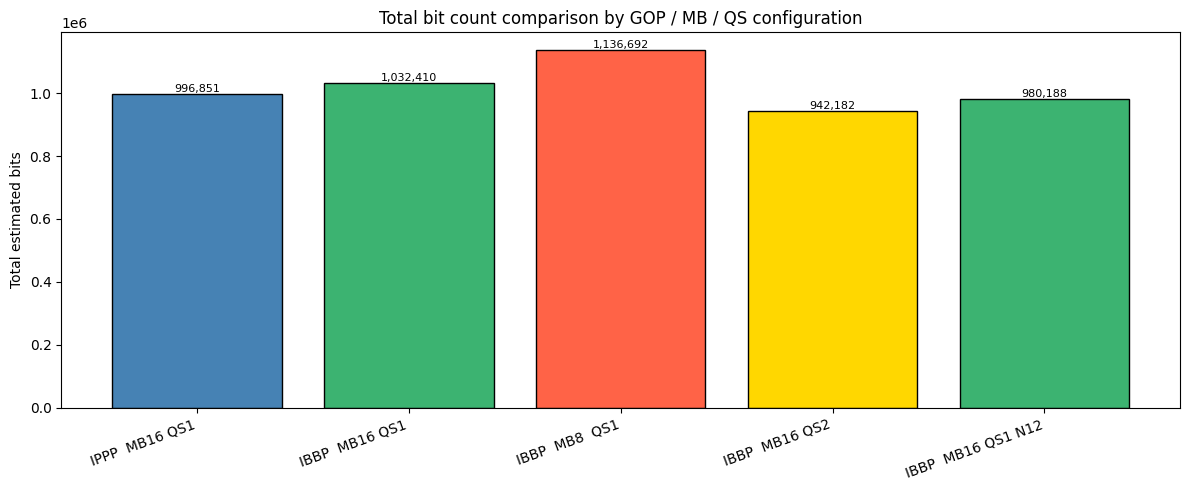

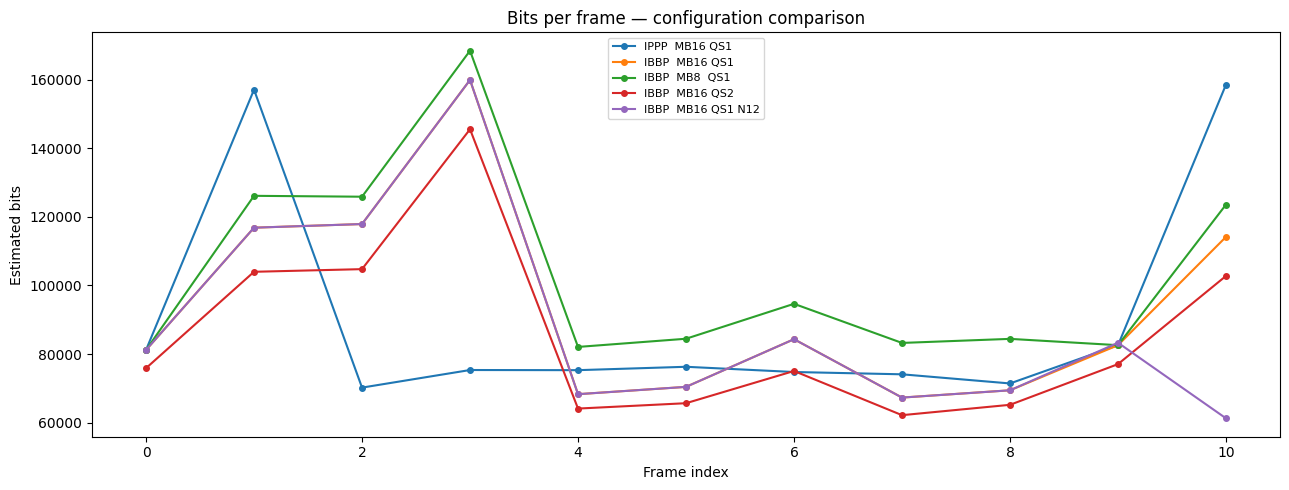


Configuration             |    Total bits |  Bits/frame |   GOP |   MB |   QS
------------------------------------------------------------------------
  IPPP  MB16 QS1          |       996,851 |    90,622.8 | N= 9 M=1 | 16px |    1
  IBBP  MB16 QS1          |     1,032,410 |    93,855.5 | N= 9 M=3 | 16px |    1
  IBBP  MB8  QS1          |     1,136,692 |   103,335.6 | N= 9 M=3 |  8px |    1
  IBBP  MB16 QS2          |       942,182 |    85,652.9 | N= 9 M=3 | 16px |    2
  IBBP  MB16 QS1 N12      |       980,188 |    89,108.0 | N=12 M=3 | 16px |    1


In [133]:
# --- Experiment analysis charts ---
if 'results' in dir() and results:

    # 1. Bar chart — total bits per configuration
    labels = [r['label'] for r in results]
    bits   = [r['bits']  for r in results]
    colors = ['steelblue' if r['M'] == 1 else
              ('tomato' if r['mb'] == 8 else
               ('gold' if r['qs'] > 1 else 'mediumseagreen'))
              for r in results]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(labels, bits, color=colors, edgecolor='black')
    ax.set_ylabel('Total estimated bits')
    ax.set_title('Total bit count comparison by GOP / MB / QS configuration')
    ax.set_xticklabels(labels, rotation=20, ha='right')
    for bar, b in zip(bars, bits):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{b:,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()

    # 2. Bits per frame — for each experiment
    if 'results_per_frame' in dir():
        fig, ax = plt.subplots(figsize=(13, 5))
        type_colors = {'I': 'red', 'P': 'blue', 'B': 'green'}
        for exp in results_per_frame:
            frame_bits = [count_bits(r['q_frame'], r['mv_list']) for r in exp['data']]
            ax.plot(frame_bits, label=exp['label'], marker='o', markersize=4)
        ax.set_xlabel('Frame index')
        ax.set_ylabel('Estimated bits')
        ax.set_title('Bits per frame — configuration comparison')
        ax.legend(fontsize=8)
        plt.tight_layout(); plt.show()

    # 3. Summary table
    print(f"\n{'Configuration':<25} | {'Total bits':>13} | {'Bits/frame':>11} | {'GOP':>5} | {'MB':>4} | {'QS':>4}")
    print("-" * 72)
    for r in results:
        n_frames = len(frames_y) if 'frames_y' in dir() else 1
        bpf = r['bits'] / n_frames
        print(f"  {r['label']:<23} | {r['bits']:>13,} | {bpf:>11,.1f} | N={r['N']:2d} M={r['M']} | {r['mb']:>2d}px | {r['qs']:>4}")



In [134]:
# =============================================================
# EXPERIMENT — MP4 Video (input.mp4)
# Uses the crop_frames_to_multiples_of_8 function from the professor
# =============================================================

VIDEO_PATH = 'video sequences/input.mp4'

if os.path.isfile(VIDEO_PATH):
    print("Extracting video frames (this may take a while)...")
    frames_video = crop_frames_to_multiples_of_8(VIDEO_PATH)
    # Limit to 30 frames for a quick demo
    frames_demo = frames_video[:30]
    print(f"Using {len(frames_demo)} frames for the experiment.")

    _, bits_video = encode_sequence(
        frames_demo,
        gop_N=9, gop_M=3,
        block_size=16, search_range=8,
        quant_scale=1,
        output_dir='compressed'
    )
    print(f"\nVideo input.mp4 (30 frames) | Estimated bits: {bits_video:,}")
else:
    print(f"[INFO] Video '{VIDEO_PATH}' not found.")


Extracting video frames (this may take a while)...
Using 30 frames for the experiment.

ENCODER | GOP N=9 M=3 | MB=16×16 | SR=8 | QS=1
GOP sequence (30 frames): ['I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'I', 'B']...
  Frame   0 [I] | estimated bits:  350,089
  Frame   1 [B] | estimated bits:  478,500
  Frame   2 [B] | estimated bits:  481,863
  Frame   3 [P] | estimated bits:  659,340
  Frame   4 [B] | estimated bits:  215,307
  Frame   5 [B] | estimated bits:  209,982
  Frame   6 [P] | estimated bits:  254,958
  Frame   7 [B] | estimated bits:  214,201
  Frame   8 [B] | estimated bits:  210,088
  Frame   9 [I] | estimated bits:  362,888
  Frame  10 [B] | estimated bits:  504,420
  Frame  11 [B] | estimated bits:  505,544
  Frame  12 [P] | estimated bits:  697,324
  Frame  13 [B] | estimated bits:  221,849
  Frame  14 [B] | estimated bits:  225,444
  Frame  15 [P] | estimated bits:  254,411
  Frame  16 [B] | estimated bits:  221,384
  Fr

In [135]:
# List the generated .npz files and display their contents
if os.path.isdir('compressed'):
    files = sorted([f for f in os.listdir('compressed') if f.endswith('.npz')])
    print(f".npz files in 'compressed/' ({len(files)} total):\n")
    print(f"{'File':<55} {'Size':>10}  {'Frames':>7}  {'Stored arrays'}") 
    print("-" * 100)
    for fname in files:
        fpath    = os.path.join('compressed', fname)
        size_kb  = os.path.getsize(fpath) / 1024
        data     = np.load(fpath, allow_pickle=True)
        n_frames = len(data['frame_types'])
        keys     = ', '.join(data.files)
        print(f"  {fname:<53} {size_kb:>9.1f} KB  {n_frames:>7}  {keys}")
        # Frame type distribution
        ftypes = data['frame_types']
        counts = {t: int(np.sum(ftypes == t)) for t in ['I','P','B']}
        print(f"    └─ Types: I={counts['I']}  P={counts['P']}  B={counts['B']}  "
              f"| QS={data['params_quant_scale']:.0f}  MB={data['params_block_size']}  "
              f"N={data['params_N']}  M={data['params_M']}")
else:
    print("Folder 'compressed/' does not exist yet. Run the experiments above.")



.npz files in 'compressed/' (5 total):

File                                                          Size   Frames  Stored arrays
----------------------------------------------------------------------------------------------------
  compressed_N12_M3_MB16_QS1.npz                            300.1 KB       11  q_frames, frame_types, frame_idxs, scales, blk_sizes, ref_idxs, bwd_idxs, mv_array, gop_seq, params_N, params_M, params_block_size, params_search_range, params_quant_scale
    └─ Types: I=1  P=3  B=7  | QS=1  MB=16  N=12  M=3
  compressed_N9_M1_MB16_QS1.npz                             313.2 KB       11  q_frames, frame_types, frame_idxs, scales, blk_sizes, ref_idxs, bwd_idxs, mv_array, gop_seq, params_N, params_M, params_block_size, params_search_range, params_quant_scale
    └─ Types: I=2  P=9  B=0  | QS=1  MB=16  N=9  M=1
  compressed_N9_M3_MB16_QS1.npz                            3294.7 KB       30  q_frames, frame_types, frame_idxs, scales, blk_sizes, ref_idxs, bwd_idxs, mv_arr

In [136]:
def decode_video_from_npz(npz_path):
    """
    Reads the compressed .npz file and reconstructs the video frames.
    Uses a 2-pass decoding strategy to handle B-frames properly.
    """
    print(f"[DECODER] Unpacking bitstream: {npz_path}")
    data = np.load(npz_path, allow_pickle=True)
    
    q_frames    = data['q_frames']
    frame_types = data['frame_types']
    scales      = data['scales']
    mb_size     = int(data['params_block_size'])
    mv_array    = data['mv_array']
    ref_idxs    = data['ref_idxs']
    bwd_idxs    = data['bwd_idxs']
    
    n_frames = len(frame_types)
    decoded_frames = [None] * n_frames
    
    # ---------------------------------------------------------
    # PASS 1: Decode Anchor Frames (I and P)
    # ---------------------------------------------------------
    for idx in range(n_frames):
        ftype = frame_types[idx]
        if ftype in ['I', 'P']:
            dq_f = dequantize_frame(q_frames[idx], mode=ftype, scale=scales[idx])
            res_rec = apply_idct_to_frame(dq_f)
            
            if ftype == 'I':
                rec_frame = res_rec
            else: # P-frame
                ref = decoded_frames[ref_idxs[idx]]
                rec_frame = np.zeros_like(res_rec)
                H, W = rec_frame.shape
                
                for mv in mv_array[idx]:
                    ri, ci, dx, dy, _ = mv[:5]
                    i, j = ri * mb_size, ci * mb_size
                    pi = np.clip(i + dx, 0, H - mb_size)
                    pj = np.clip(j + dy, 0, W - mb_size)
                    pred = ref[pi:pi+mb_size, pj:pj+mb_size]
                    rec_frame[i:i+mb_size, j:j+mb_size] = pred + res_rec[i:i+mb_size, j:j+mb_size]
                    
            decoded_frames[idx] = np.clip(rec_frame, 0, 255).astype(np.uint8)

    # ---------------------------------------------------------
    # PASS 2: Decode Bidirectional Frames (B)
    # ---------------------------------------------------------
    for idx in range(n_frames):
        if frame_types[idx] == 'B':
            dq_f = dequantize_frame(q_frames[idx], mode='B', scale=scales[idx])
            res_rec = apply_idct_to_frame(dq_f)
            
            ref_fwd = decoded_frames[ref_idxs[idx]]
            ref_bwd = decoded_frames[bwd_idxs[idx]]
            
            # --- FIX FOR TRUNCATED SEQUENCES (OPEN GOP) ---
            # If the video ended on a B-frame, there is no future anchor.
            # We fallback to using the forward reference for both.
            if ref_bwd is None:
                ref_bwd = ref_fwd
            # ----------------------------------------------

            rec_frame = np.zeros_like(res_rec)
            H, W = rec_frame.shape
            
            for mv in mv_array[idx]:
                if len(mv) == 7:
                    ri, ci, dx_f, dy_f, dx_b, dy_b, _ = mv
                    i, j = ri * mb_size, ci * mb_size
                    
                    pi_f = np.clip(i + dx_f, 0, H - mb_size)
                    pj_f = np.clip(j + dy_f, 0, W - mb_size)
                    pred_f = ref_fwd[pi_f:pi_f+mb_size, pj_f:pj_f+mb_size]
                    
                    pi_b = np.clip(i + dx_b, 0, H - mb_size)
                    pj_b = np.clip(j + dy_b, 0, W - mb_size)
                    pred_b = ref_bwd[pi_b:pi_b+mb_size, pj_b:pj_b+mb_size]
                    
                    pred = (pred_f.astype(float) + pred_b.astype(float)) / 2.0
                    rec_frame[i:i+mb_size, j:j+mb_size] = pred + res_rec[i:i+mb_size, j:j+mb_size]
                    
            decoded_frames[idx] = np.clip(rec_frame, 0, 255).astype(np.uint8)
            
    print("[DECODER] Decoding complete!")
    return decoded_frames

# =============================================================
# PLAY THE RECONSTRUCTED VIDEO
# =============================================================
import glob
import matplotlib.animation as animation  # <-- Faltava isto!
from IPython.display import HTML          # <-- E isto para mostrar o vídeo no Jupyter!

# Find the specific file with QS=1 and N=12 (highest quality IBBP we tested)
test_file = glob.glob('compressed/compressed_N12_M3_MB16_QS1.npz')

if test_file:
    recovered_video = decode_video_from_npz(test_file[0])
    
    # Create the Matplotlib Video Player
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('off')
    ax.set_title("Reconstructed Video Output")
    
    # First frame
    im = ax.imshow(recovered_video[0], cmap='gray', vmin=0, vmax=255)
    
    def update(frame_idx):
        im.set_array(recovered_video[frame_idx])
        ax.set_title(f"Reconstructed Video Output | Frame {frame_idx+1}/{len(recovered_video)}")
        return [im]
    
    ani = animation.FuncAnimation(fig, update, frames=len(recovered_video), interval=100, blit=True)
    
    # Display as an interactive HTML5 video in the Jupyter Notebook
    display(HTML(ani.to_jshtml()))
    plt.close()
else:
    print("Could not find the target .npz file to play.")

[DECODER] Unpacking bitstream: compressed/compressed_N12_M3_MB16_QS1.npz
[DECODER] Decoding complete!


To validate the structural integrity of our serialized bitstream, we implemented an early prototype of the decoder. 

This uncovers a fundamental challenge in video decoding: **Out-of-Order Execution**. Because B-frames require future frames for motion compensation, they cannot be decoded sequentially. Our decoder solves this by employing a two-pass strategy:
1. **Pass 1:** It extracts, inverse quantizes, and applies the IDCT to all anchor frames (I and P), fully reconstructing their pixels and storing them in memory.
2. **Pass 2:** It iterates through the sequence again, identifying B-frames. It loads the previously reconstructed forward and backward anchors from memory, applies bidirectional motion compensation, adds the decoded residual, and outputs the final frame.

The resulting interactive playback visually confirms that the pipeline is fully operational. Despite discarding vast amounts of data during the spatial and temporal compression phases, the reconstructed sequence maintains smooth motion and highly recognizable geometries, perfectly setting the stage for the rigorous objective quality analysis (PSNR/SSIM) required in Part 2.

---
## Conclusion

In a real-world scenario (like an MP4 or MKV file), the encoded data is multiplexed and packed into a binary bitstream. In our educational implementation, we emulate this process by serializing the encoder's output into a highly efficient `.npz` (NumPy compressed) archive. This single file acts as our final "video container."

Inside each configuration-specific archive, the data is meticulously structured into two main logical categories:

**1. The Video Payload (The Encoded Data)**
* `q_frames`: The quantized DCT coefficients (spatial data and residuals). Thanks to the energy compaction and quantization matrices, this array is highly sparse, driving the massive reduction in file size.
* `mv_array`: The motion vectors for P and B frames (the temporal instructions).

**2. The Sequence Headers & Metadata (The Decoder's Blueprint)**
* `frame_types` & `gop_seq`: The structural blueprint of the GOP. This tells the future decoder exactly which decoding path to execute (Intra, Predictive, or Bidirectional) for each frame.
* `ref_idxs` & `bwd_idxs`: The Reference Picture Lists (RPL). These indices point the decoder to the exact past or future frames required to resolve motion compensation.
* `params_*`: The active encoding parameters (Quantization Scale, Macroblock Size, Search Range).






